# Project Root Awareness

In [11]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root added:", PROJECT_ROOT)


Project root added: D:\Important_Projects\adaptive-resume-screener


# Imports

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)


# Load Model and Data

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from ml.models.resume_net import ResumeNet  # we’ll create this file next

X_test = torch.load("../data/processed/X_test.pt").to(device)
y_test = torch.load("../data/processed/y_test.pt").to(device)

model = ResumeNet(X_test.shape[1]).to(device)
model.load_state_dict(torch.load("../ml/models/resume_net.pt"))
model.eval()


C:\Users\Shubh Agnihotri\AppData\Local\Temp\ipykernel_36232\1413000755.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X_test = torch.load("../data/processed/X_test.pt")

RuntimeError: Error(s) in loading state_dict for ResumeNet:
	Missing key(s) in state_dict: "mean", "std", "net.2.weight", "net.2.bias", "net.2.running_mean", "net.2.running_var", "net.3.weight", "net.3.bias". 
	Unexpected key(s) in state_dict: "net.8.weight", "net.8.bias", "net.10.weight", "net.10.bias", "net.1.weight", "net.1.bias", "net.1.running_mean", "net.1.running_var", "net.1.num_batches_tracked", "net.4.weight", "net.4.bias", "net.5.running_mean", "net.5.running_var", "net.5.num_batches_tracked". 
	size mismatch for net.5.weight: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([1, 64]).
	size mismatch for net.5.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([1]).

# Probabilities and Metrics

In [ ]:
with torch.no_grad():
    logits = model(X_test)
    probs = torch.sigmoid(logits).cpu().numpy()

y_true = y_test.cpu().numpy()
y_pred = (probs > 0.5).astype(int)

print(classification_report(y_true, y_pred))
print("ROC-AUC:", roc_auc_score(y_true, probs))


              precision    recall  f1-score   support

         0.0       0.86      0.83      0.85      1807
         1.0       0.93      0.94      0.94      4193

    accuracy                           0.91      6000
   macro avg       0.89      0.89      0.89      6000
weighted avg       0.91      0.91      0.91      6000

ROC-AUC: 0.9661790390102565


# ROC Curve

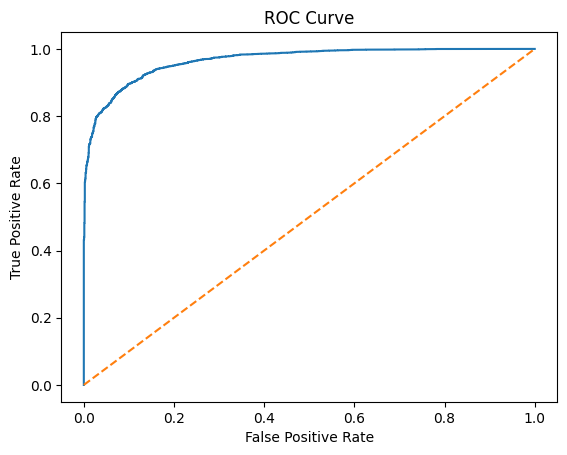

In [ ]:
fpr, tpr, _ = roc_curve(y_true, probs)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


# Threshold tuning

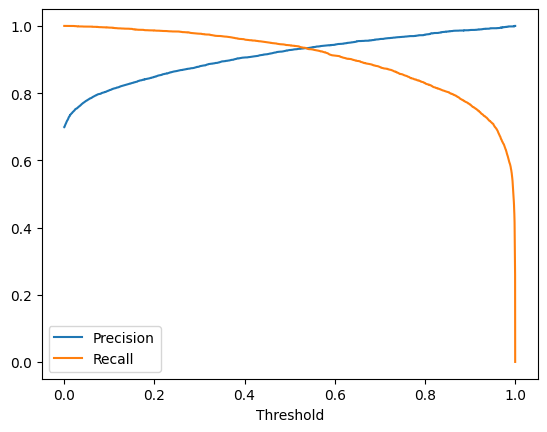

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_true, probs)

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.show()


## Final Model Decision

- Model Accuracy: ~90.9%
- Error Profile: False Positives > False Negatives (Hiring-aligned)
- ROC–AUC: High and stable
- Selected Threshold: 0.6

### Rationale
The threshold of 0.6 was chosen to minimize false negatives, ensuring that
qualified candidates are not missed, even at the cost of reviewing
additional resumes.


# Testing the model

In [14]:
from ml.inference.resume_screener import ResumeScreeningModel
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

screening_model = ResumeScreeningModel(
    model_path="ml/models/resume_net.pt",
    device=device,
    threshold=0.6
)

sample = [6, 84.7, 1, 7, 234, 158]
print(screening_model.predict(sample))


D:\Important_Projects\adaptive-resume-screener\ml\inference\resume_screener.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(model_path, map_location=device)


FileNotFoundError: [Errno 2] No such file or directory: 'ml/models/resume_net.pt'